# 🏠 NYC Airbnb Data Cleaning & Reporting Automation

## Data Profiling & Quality Assessment

**Project:** Automated Data Cleaning & Reporting System  
**Dataset:** NYC Airbnb Open Data  
**File:** `AB_NYC_2019.csv`

---

### Purpose

This notebook performs an initial **data profiling and quality assessment** of the raw NYC Airbnb dataset.

The profiling stage identifies:

- Dataset structure
- Data types
- Missing values
- Duplicate records
- Invalid values
- Categorical inconsistencies
- Numerical anomalies
- Potential outliers

The results from this notebook will be used to design the automated data-cleaning pipeline.

## 🎯 Project Objective

The objective of this project is to develop an automated workflow that:

1. Loads raw Airbnb listing data.
2. Profiles the dataset and identifies data-quality issues.
3. Cleans missing, duplicate, inconsistent, and invalid data.
4. Validates the cleaned dataset.
5. Performs meaningful data analysis.
6. Generates visual summaries and business insights.
7. Produces an automated Excel report.

### Current Phase

**Phase 1 — Data Profiling**

In this notebook, the raw dataset is analyzed without modifying the original data.

In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the raw Airbnb dataset

df = pd.read_csv("../data/raw/AB_NYC_2019.csv")

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (48895, 16)


## 📊 Dataset Overview

The NYC Airbnb dataset contains information about Airbnb listings in New York City.

The dataset includes information related to:

- Listing details
- Host information
- Location
- Room type
- Pricing
- Reviews
- Availability

Each row represents an Airbnb listing, while each column represents a specific attribute of that listing.

The original raw dataset is preserved and will not be modified during this profiling stage.

In [5]:
# Display the number of rows and columns

rows, columns = df.shape

print(f"Number of Rows: {rows:,}")
print(f"Number of Columns: {columns}")

Number of Rows: 48,895
Number of Columns: 16


## 👀 Data Preview

The first few records are displayed to understand the structure, values, and formatting of the raw dataset.

In [6]:
# Display the first five records

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
# Display five randomly selected records

df.sample(5, random_state=42)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
879,317905,Come and go as you please in BKLN!,1631733,Jane,Brooklyn,Kensington,40.64354,-73.97777,Entire home/apt,89,3,62,2019-01-02,0.71,1,189
44383,34205267,"Spacious, sunny room in Queens/Brooklyn",913940,Giancarlo,Queens,Ridgewood,40.70666,-73.90779,Private room,30,21,0,NaN,NaN,1,73
15394,12342297,Private bedroom in high-ceiling 4BR apartment!,19953913,Alejandro,Manhattan,Hell's Kitchen,40.76116,-73.99016,Private room,120,2,17,2017-04-28,0.43,1,0
43230,33527778,Sonder | Stock Exchange | Stunning 3BR + Kitchen,219517861,Sonder (NYC),Manhattan,Financial District,40.70763,-74.01050,Entire home/apt,470,2,5,2019-06-02,1.88,327,272
16332,13136376,Spacious 2 Bedroom with Balcony,16110448,Gingie,Manhattan,East Harlem,40.79658,-73.93287,Entire home/apt,199,2,30,2019-06-03,0.80,1,30


## 🔍 Dataset Structure & Information

This section examines:

- Column names
- Data types
- Number of non-null values
- Memory usage

Understanding the structure is important before designing the automated cleaning rules.

In [8]:
# Display all column names

print("Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:

1. id
2. name
3. host_id
4. host_name
5. neighbourhood_group
6. neighbourhood
7. latitude
8. longitude
9. room_type
10. price
11. minimum_nights
12. number_of_reviews
13. last_review
14. reviews_per_month
15. calculated_host_listings_count
16. availability_365


In [9]:
# Display data types of all columns

df.dtypes

id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [10]:
# Display detailed information about the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

## 📈 Statistical Summary

A statistical summary is generated for the numerical variables.

This helps us understand:

- Count
- Mean
- Standard deviation
- Minimum values
- Quartiles
- Maximum values

Extreme values identified here will be investigated further during the data-cleaning phase.

In [11]:
# Generate statistical summary for numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


## 🚨 Missing Value Analysis

Missing values are one of the main data-quality issues that need to be evaluated.

This section identifies:

- Number of missing values
- Percentage of missing values
- Columns affected by missing data

The missing values will only be identified at this stage.

> **No missing values are modified or removed in this notebook.**

In [12]:
# Calculate missing values and their percentages

missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Show only columns containing missing values
missing_report = missing_report[
    missing_report["Missing Count"] > 0
].sort_values(
    "Missing Count",
    ascending=False
)

missing_report

,Missing Count,Missing Percentage
reviews_per_month,10052,20.56
last_review,10052,20.56
host_name,21,0.04
name,16,0.03


### 📊 Missing Values by Column

The following visualization shows the number of missing values present in each affected column.

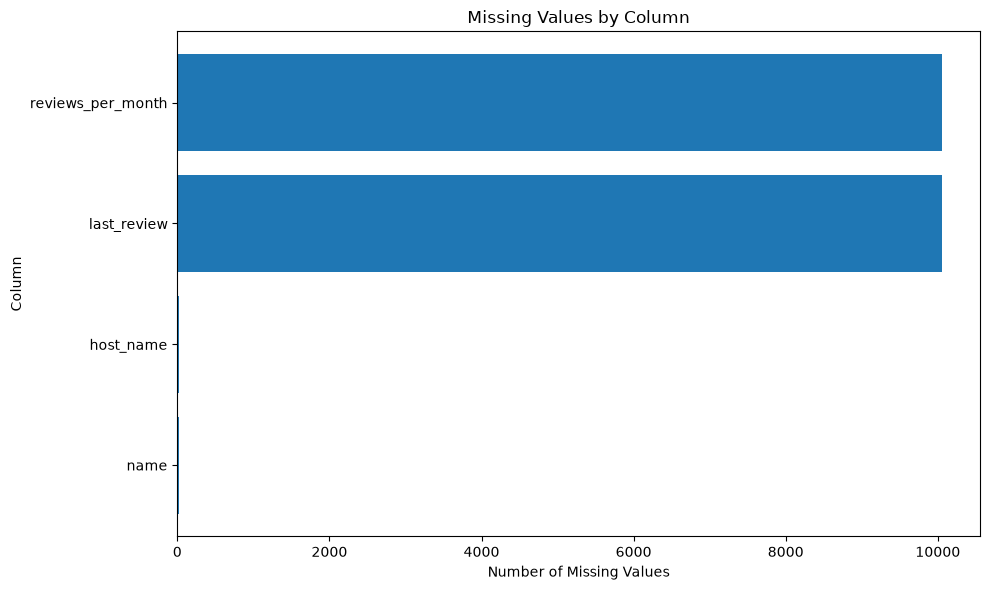

In [13]:
# Visualize missing values

plt.figure(figsize=(10, 6))

missing_plot = missing_report.sort_values(
    "Missing Count",
    ascending=True
)

plt.barh(
    missing_plot.index,
    missing_plot["Missing Count"]
)

plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.title("Missing Values by Column")

plt.tight_layout()
plt.show()

## ♻️ Duplicate Record Analysis

Duplicate records can cause:

- Incorrect counts
- Inflated statistics
- Misleading reports
- Inaccurate business insights

Two types of duplication will be investigated:

1. Complete duplicate rows
2. Duplicate listing IDs

The original dataset will not be modified.

In [14]:
# Check for complete duplicate rows

duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


In [15]:
# Check for duplicate listing IDs

duplicate_ids = df["id"].duplicated().sum()

print(f"Duplicate Listing IDs: {duplicate_ids}")

Duplicate Listing IDs: 0


## 🏷️ Categorical Data Analysis

Categorical variables are examined to understand their unique values and distributions.

Important categorical variables include:

- Neighbourhood Group
- Neighbourhood
- Room Type

This analysis can help identify unexpected or inconsistent categories that may require standardization.

In [16]:
# Distribution of neighbourhood groups

neighbourhood_group_counts = df["neighbourhood_group"].value_counts()

neighbourhood_group_counts

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [17]:
# Distribution of room types

room_type_counts = df["room_type"].value_counts()

room_type_counts

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [18]:
# Number of unique neighbourhoods

unique_neighbourhoods = df["neighbourhood"].nunique()

print(f"Number of Unique Neighbourhoods: {unique_neighbourhoods}")

Number of Unique Neighbourhoods: 221


In [19]:
# Display the 15 most common neighbourhoods

df["neighbourhood"].value_counts().head(15)

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
East Harlem           1117
Greenpoint            1115
Chelsea               1113
Lower East Side        911
Astoria                900
Name: count, dtype: int64

## ⚠️ Numerical Data Validation

Numerical columns are checked for logically invalid values.

The following validation rules are considered:

- Price should not be negative.
- Minimum nights should be greater than zero.
- Availability should be between 0 and 365 days.
- Review counts should not be negative.

These checks help us identify records that may require correction or removal during the cleaning phase.

In [20]:
# Check price values

zero_price = (df["price"] == 0).sum()
negative_price = (df["price"] < 0).sum()

print(f"Zero Price Records: {zero_price}")
print(f"Negative Price Records: {negative_price}")

Zero Price Records: 11
Negative Price Records: 0


In [21]:
# Check minimum nights

invalid_nights = (df["minimum_nights"] <= 0).sum()

print(f"Invalid Minimum Nights: {invalid_nights}")

Invalid Minimum Nights: 0


In [22]:
# Check availability values

invalid_availability = (
    (df["availability_365"] < 0) |
    (df["availability_365"] > 365)
).sum()

print(f"Invalid Availability Records: {invalid_availability}")

Invalid Availability Records: 0


In [23]:
# Check number of reviews

negative_reviews = (
    df["number_of_reviews"] < 0
).sum()

print(f"Negative Review Count Records: {negative_reviews}")

Negative Review Count Records: 0


## 📦 Outlier Analysis

Outliers are unusually high or low observations that differ significantly from the majority of the data.

For this dataset, particular attention will be given to:

- Price
- Minimum nights
- Number of reviews
- Availability

Outliers will be investigated rather than automatically deleted because an extreme value may represent a legitimate Airbnb listing.

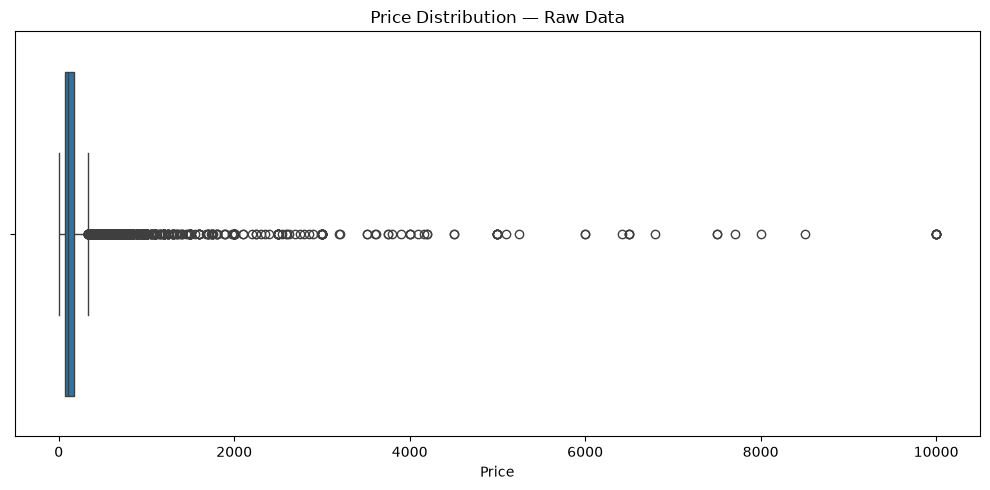

In [24]:
# Visualize price outliers

plt.figure(figsize=(10, 5))

sns.boxplot(x=df["price"])

plt.title("Price Distribution — Raw Data")
plt.xlabel("Price")

plt.tight_layout()
plt.show()

In [25]:
# Display detailed price statistics

price_statistics = df["price"].describe()

price_statistics

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [26]:
# Display important price metrics

print(f"Median Price: ${df['price'].median():,.2f}")
print(f"Maximum Price: ${df['price'].max():,.2f}")

Median Price: $106.00
Maximum Price: $10,000.00


## 📋 Data Quality Baseline — BEFORE CLEANING

This section creates a baseline summary of the raw dataset.

The metrics below represent the state of the data **before any cleaning operations**.

These values will later be compared with the results after automated cleaning.

### Quality Dimensions

- Missing values
- Duplicate records
- Duplicate IDs
- Zero/negative prices
- Invalid minimum nights
- Invalid availability
- Negative review counts

In [27]:
# Create the raw data quality summary

quality_summary = {
    "Total Rows": len(df),
    "Total Columns": len(df.columns),
    "Total Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Duplicate IDs": df["id"].duplicated().sum(),
    "Zero Price Records": (df["price"] == 0).sum(),
    "Negative Price Records": (df["price"] < 0).sum(),
    "Invalid Minimum Nights": (df["minimum_nights"] <= 0).sum(),
    "Invalid Availability": (
        (df["availability_365"] < 0) |
        (df["availability_365"] > 365)
    ).sum(),
    "Negative Review Counts": (
        df["number_of_reviews"] < 0
    ).sum()
}

quality_summary

{'Total Rows': 48895,
 'Total Columns': 16,
 'Total Missing Values': np.int64(20141),
 'Duplicate Rows': np.int64(0),
 'Duplicate IDs': np.int64(0),
 'Zero Price Records': np.int64(11),
 'Negative Price Records': np.int64(0),
 'Invalid Minimum Nights': np.int64(0),
 'Invalid Availability': np.int64(0),
 'Negative Review Counts': np.int64(0)}

In [28]:
# Convert quality summary into a DataFrame

quality_summary_df = pd.DataFrame(
    list(quality_summary.items()),
    columns=["Quality Metric", "Value"]
)

quality_summary_df

,Quality Metric,Value
0,Total Rows,48895
1,Total Columns,16
2,Total Missing Values,20141
3,Duplicate Rows,0
4,Duplicate IDs,0
5,Zero Price Records,11
6,Negative Price Records,0
7,Invalid Minimum Nights,0
8,Invalid Availability,0
9,Negative Review Counts,0


## 📝 Profiling Conclusions

The initial profiling stage provides a baseline understanding of the raw Airbnb dataset.

The analysis evaluated:

- Dataset dimensions and structure
- Data types
- Missing values
- Duplicate records
- Duplicate listing IDs
- Categorical distributions
- Numerical validity
- Price distribution and potential outliers

### Key Findings

The identified data-quality issues will be addressed in the next stage of the project.

### Next Phase

The next notebook will implement the **automated data-cleaning pipeline**, including:

1. Missing value handling
2. Duplicate removal
3. Data-type corrections
4. Text standardization
5. Invalid-value handling
6. Outlier treatment
7. Data validation

> **The original raw dataset remains unchanged.**